# DS605 Lab Assignment 3
## Scikit-learn: Data Preprocessing and Model Performance Evaluation

**Dataset:** Kaggle Hotel Booking Demand (`hotel_bookings.csv`)

This notebook:
- Loads and explores the dataset
- Checks missing values, leakage, and outliers
- Creates two preprocessing pipelines
- Trains Logistic Regression and Decision Tree classifiers
- Compares all four experiments
- Displays confusion matrices for the best result of each model

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

## 2. Load and Understand the Dataset

In [2]:
# Make sure hotel_bookings.csv is in the same folder as this notebook.
df = pd.read_csv("hotel_bookings.csv")

print("First 5 rows:")
display(df.head())

print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all"))

print("\nData types:")
display(df.dtypes)

print("\nClass distribution of is_canceled:")
display(df["is_canceled"].value_counts())
display(df["is_canceled"].value_counts(normalize=True) * 100)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Dataset shape: (119390, 32)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                      

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390,118902,119390,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390.000000,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92310,48590,56477,97870,NaN,NaN,NaN,85994,74053,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,NaN,NaN,NaN,NaN,0.031912,0.087118,0.137097,NaN,NaN,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,NaN,NaN,NaN,NaN,0.175767,0.844336,1.497437,NaN,NaN,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN



Data types:


hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             


Class distribution of is_canceled:


is_canceled
0    75166
1    44224
Name: count, dtype: int64

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

## 3. Missing Values

In [3]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
}).sort_values("Missing Percentage", ascending=False)

display(missing_summary)

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


## 4. Remove Leakage Columns and High-Missingness Columns

`reservation_status` and `reservation_status_date` are removed because they directly reveal or strongly depend on the final booking outcome. Columns with extremely high missingness are also removed when justified.

In [4]:
# Columns that cause target leakage
leakage_columns = ["reservation_status", "reservation_status_date"]

# Identify columns with very high missingness (more than 90%)
high_missing_columns = missing_summary[
    missing_summary["Missing Percentage"] > 90
].index.tolist()

print("High-missingness columns (>90%):", high_missing_columns)
print("Leakage columns:", leakage_columns)

columns_to_drop = list(set(
    [col for col in leakage_columns if col in df.columns] +
    high_missing_columns
))

df_clean = df.drop(columns=columns_to_drop)

print("\nColumns dropped:", columns_to_drop)
print("Shape after dropping columns:", df_clean.shape)

High-missingness columns (>90%): ['company']
Leakage columns: ['reservation_status', 'reservation_status_date']

Columns dropped: ['company', 'reservation_status', 'reservation_status_date']
Shape after dropping columns: (119390, 29)


## 5. Check Selected Numerical Features for Outliers

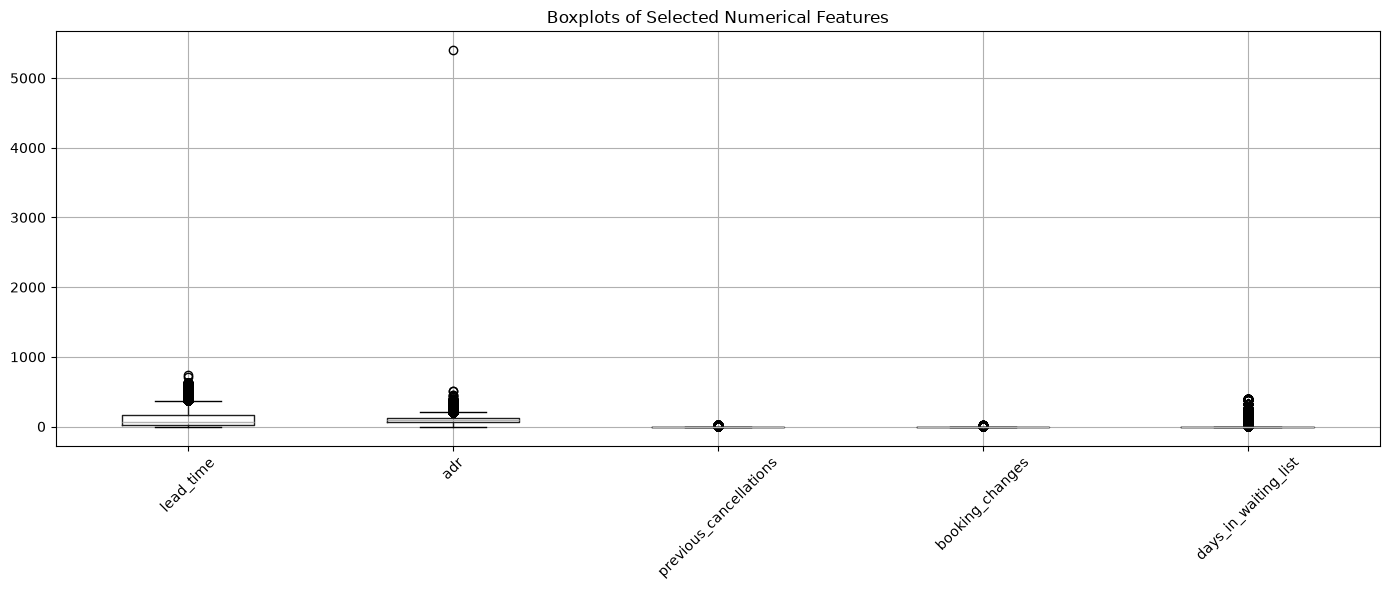

In [5]:
selected_numeric = [
    "lead_time", "adr",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list"
]

selected_numeric = [col for col in selected_numeric if col in df_clean.columns]

plt.figure(figsize=(14, 6))
df_clean[selected_numeric].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Selected Numerical Features")
plt.tight_layout()
plt.show()

## 6. Remove Clear/Extreme Outliers Using the IQR Method

The IQR rule is applied only to selected numerical features. To avoid removing too much valid hotel-booking data, the notebook uses a conservative **3 × IQR** range for extreme outliers.

In [6]:
rows_before = len(df_clean)

# Conservative extreme-outlier removal using 3 * IQR
outlier_mask = pd.Series(False, index=df_clean.index)

for col in selected_numeric:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    col_outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_mask = outlier_mask | col_outliers

df_model = df_clean.loc[~outlier_mask].copy()

rows_removed = rows_before - len(df_model)

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", len(df_model))
print("Number of rows removed:", rows_removed)
print("Percentage removed:", round((rows_removed / rows_before) * 100, 2), "%")

Rows before outlier removal: 119390
Rows after outlier removal: 92182
Number of rows removed: 27208
Percentage removed: 22.79 %


## 7. Define Target and Features

In [7]:
# Target
y = df_model["is_canceled"]

# Features
X = df_model.drop(columns=["is_canceled"])

# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("Numerical columns:", numerical_columns)

print("\nNumber of categorical columns:", len(categorical_columns))
print("Categorical columns:", categorical_columns)

Number of numerical columns: 18
Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Number of categorical columns: 10
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


## 8. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (73745, 28)
Testing shape: (18437, 28)


## 9. Create Pipeline A: KNNImputer + StandardScaler

In [9]:
numeric_pipeline_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer(transformers=[
    ("num", numeric_pipeline_A, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

## 10. Create Pipeline B: KNNImputer + MinMaxScaler

In [10]:
numeric_pipeline_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

preprocessor_B = ColumnTransformer(transformers=[
    ("num", numeric_pipeline_B, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

## 11. Create Four Model-Pipeline Combinations

In [11]:
experiments = {
    "Logistic Regression + Pipeline A (StandardScaler)": Pipeline(steps=[
        ("preprocessor", preprocessor_A),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Logistic Regression + Pipeline B (MinMaxScaler)": Pipeline(steps=[
        ("preprocessor", preprocessor_B),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree + Pipeline A (StandardScaler)": Pipeline(steps=[
        ("preprocessor", preprocessor_A),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Decision Tree + Pipeline B (MinMaxScaler)": Pipeline(steps=[
        ("preprocessor", preprocessor_B),
        ("model", DecisionTreeClassifier(random_state=42))
    ])
}

## 12. Train and Evaluate All Four Experiments

In [12]:
results = []
trained_models = {}

for name, pipeline in experiments.items():
    print(f"Training: {name}")

    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    results.append({
        "Model + Pipeline": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Difference": train_accuracy - test_accuracy
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

Training: Logistic Regression + Pipeline A (StandardScaler)
Training: Logistic Regression + Pipeline B (MinMaxScaler)
Training: Decision Tree + Pipeline A (StandardScaler)
Training: Decision Tree + Pipeline B (MinMaxScaler)


,Model + Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Decision Tree + Pipeline B (MinMaxScaler),0.995552,0.848999,0.793119,0.795232,0.794174,0.146553
1,Decision Tree + Pipeline A (StandardScaler),0.995552,0.848728,0.792793,0.794788,0.793789,0.146824
2,Logistic Regression + Pipeline A (StandardScaler),0.801139,0.797201,0.775342,0.628516,0.694251,0.003938
3,Logistic Regression + Pipeline B (MinMaxScaler),0.800258,0.796876,0.775701,0.626740,0.693309,0.003382


## 13. Identify the Best Logistic Regression and Decision Tree Results

In [13]:
lr_results = results_df[
    results_df["Model + Pipeline"].str.contains("Logistic Regression")
]

dt_results = results_df[
    results_df["Model + Pipeline"].str.contains("Decision Tree")
]

best_lr_name = lr_results.loc[lr_results["F1-Score"].idxmax(), "Model + Pipeline"]
best_dt_name = dt_results.loc[dt_results["F1-Score"].idxmax(), "Model + Pipeline"]

print("Best Logistic Regression:", best_lr_name)
print("Best Decision Tree:", best_dt_name)

Best Logistic Regression: Logistic Regression + Pipeline A (StandardScaler)
Best Decision Tree: Decision Tree + Pipeline B (MinMaxScaler)


## 14. Confusion Matrix for Best Logistic Regression

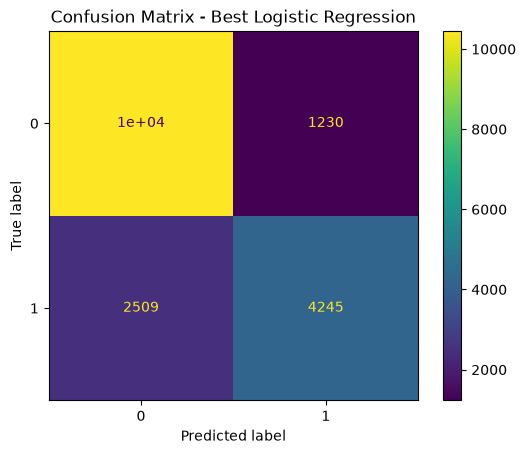

In [14]:
best_lr_model = trained_models[best_lr_name]
y_pred_lr = best_lr_model.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=best_lr_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Best Logistic Regression")
plt.show()

## 15. Confusion Matrix for Best Decision Tree

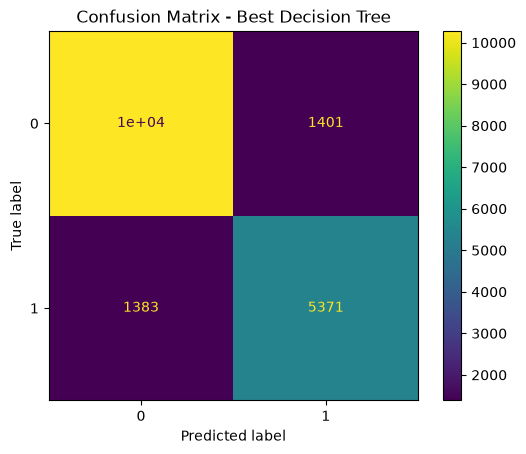

In [15]:
best_dt_model = trained_models[best_dt_name]
y_pred_dt = best_dt_model.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=best_dt_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Best Decision Tree")
plt.show()

## 16. Check Possible Overfitting

In [16]:
overfitting_table = results_df[
    ["Model + Pipeline", "Training Accuracy", "Testing Accuracy", "Train-Test Difference"]
].copy()

display(overfitting_table)

print("\nInterpretation:")
for _, row in overfitting_table.iterrows():
    if row["Train-Test Difference"] > 0.10:
        print(f"- {row['Model + Pipeline']}: Large difference, possible overfitting.")
    else:
        print(f"- {row['Model + Pipeline']}: Smaller difference, less evidence of serious overfitting.")

,Model + Pipeline,Training Accuracy,Testing Accuracy,Train-Test Difference
0,Decision Tree + Pipeline B (MinMaxScaler),0.995552,0.848999,0.146553
1,Decision Tree + Pipeline A (StandardScaler),0.995552,0.848728,0.146824
2,Logistic Regression + Pipeline A (StandardScaler),0.801139,0.797201,0.003938
3,Logistic Regression + Pipeline B (MinMaxScaler),0.800258,0.796876,0.003382



Interpretation:
- Decision Tree + Pipeline B (MinMaxScaler): Large difference, possible overfitting.
- Decision Tree + Pipeline A (StandardScaler): Large difference, possible overfitting.
- Logistic Regression + Pipeline A (StandardScaler): Smaller difference, less evidence of serious overfitting.
- Logistic Regression + Pipeline B (MinMaxScaler): Smaller difference, less evidence of serious overfitting.


## 17. Final Observations

In [17]:
best_overall = results_df.iloc[0]

print("1. Best overall combination:")
print(best_overall["Model + Pipeline"])

print("\n2. Logistic Regression comparison:")
display(lr_results)

print("\n3. Decision Tree comparison:")
display(dt_results)

print("\n4. Suggested observations to include in the report:")
print("- The best model is the one with the strongest overall testing accuracy and F1-score.")
print("- StandardScaler and MinMaxScaler may affect Logistic Regression because it is sensitive to feature scale.")
print("- Decision Trees are generally less sensitive to feature scaling.")
print("- A large gap between training and testing accuracy suggests possible overfitting.")
print("- The confusion matrices show how well each best model distinguishes canceled and non-canceled bookings.")

1. Best overall combination:
Decision Tree + Pipeline B (MinMaxScaler)

2. Logistic Regression comparison:


,Model + Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
2,Logistic Regression + Pipeline A (StandardScaler),0.801139,0.797201,0.775342,0.628516,0.694251,0.003938
3,Logistic Regression + Pipeline B (MinMaxScaler),0.800258,0.796876,0.775701,0.626740,0.693309,0.003382



3. Decision Tree comparison:


,Model + Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Decision Tree + Pipeline B (MinMaxScaler),0.995552,0.848999,0.793119,0.795232,0.794174,0.146553
1,Decision Tree + Pipeline A (StandardScaler),0.995552,0.848728,0.792793,0.794788,0.793789,0.146824



4. Suggested observations to include in the report:
- The best model is the one with the strongest overall testing accuracy and F1-score.
- StandardScaler and MinMaxScaler may affect Logistic Regression because it is sensitive to feature scale.
- Decision Trees are generally less sensitive to feature scaling.
- A large gap between training and testing accuracy suggests possible overfitting.
- The confusion matrices show how well each best model distinguishes canceled and non-canceled bookings.


# Submission Notes

Before submitting:

1. Run **Kernel → Restart Kernel and Run All Cells**.
2. Ensure `hotel_bookings.csv` is in the same folder as the notebook.
3. Save the notebook.
4. Create a public GitHub repository containing:
   - This `.ipynb` file
   - `README.md`
   - The cleaned base dataset used for modeling, if required
5. Submit only the public GitHub repository link.